## Подготовка данных

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [17]:
df = pd.read_csv('H:/projects/AI Impact on Student Life Dataset/AI_Student_Life_india.csv')

In [18]:
print("Размер:", df.shape)
df.head()

Размер: (400, 10)


,Student_ID,Age,Gender,Education_Level,City,AI_Tool_Used,Daily_Usage_Hours,Purpose,Impact_on_Grades,Satisfaction_Level
0,1,15,Female,College,Hyderabad,Copilot,1.1,Learning,Slight Decline,Medium
1,2,21,Female,University,Chennai,Copilot,1.7,Coding,Slight Decline,High
2,3,22,Male,University,Bangalore,Gemini,1.5,Learning,Improved,Low
3,4,22,Male,College,Hyderabad,ChatGPT,3.8,Research,Improved,Low
4,5,22,Male,College,Hyderabad,Gemini,5.2,Coding,Slight Decline,Low


## Чистка данных

In [19]:
print(df.info())
print("\nПропуски:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          400 non-null    int64  
 1   Age                 400 non-null    int64  
 2   Gender              400 non-null    object 
 3   Education_Level     400 non-null    object 
 4   City                400 non-null    object 
 5   AI_Tool_Used        400 non-null    object 
 6   Daily_Usage_Hours   400 non-null    float64
 7   Purpose             400 non-null    object 
 8   Impact_on_Grades    400 non-null    object 
 9   Satisfaction_Level  400 non-null    object 
dtypes: float64(1), int64(2), object(7)
memory usage: 31.4+ KB
None

Пропуски:
 Student_ID            0
Age                   0
Gender                0
Education_Level       0
City                  0
AI_Tool_Used          0
Daily_Usage_Hours     0
Purpose               0
Impact_on_Grades      0
Satisfactio

In [20]:
print(f"Дубликатов: {df.duplicated().sum()}")

Дубликатов: 0


## EDA

### Общая статистика

In [37]:
df[['Age', 'Daily_Usage_Hours']].describe()

,Age,Daily_Usage_Hours
count,400.000000,400.000000
mean,19.425000,2.933750
std,2.991948,1.589939
min,15.000000,0.500000
25%,17.000000,1.575000
50%,19.500000,2.900000
75%,22.000000,4.200000
max,25.000000,6.000000


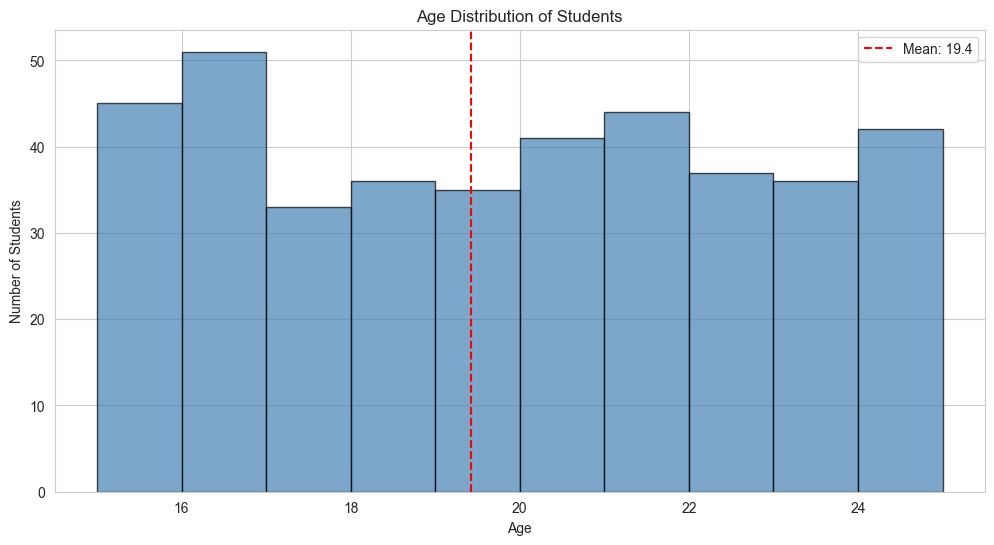

In [39]:
plt.hist(df['Age'], bins=10, edgecolor='black', alpha=0.7, color='steelblue' )
plt.xlabel('Age')
plt.ylabel('Number of Students')
plt.title('Age Distribution of Students')
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
plt.legend()
plt.show()

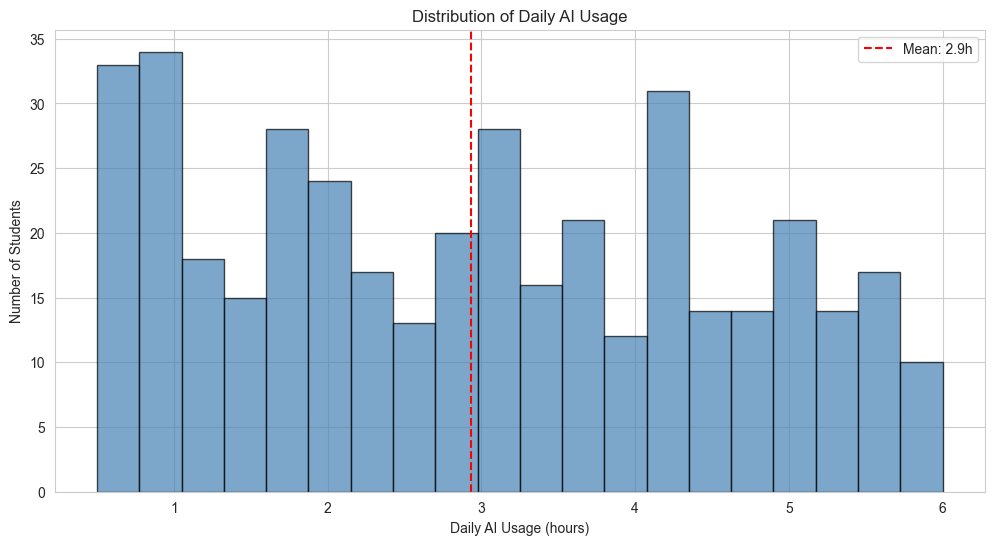

In [43]:
plt.hist(df['Daily_Usage_Hours'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Daily AI Usage (hours)')
plt.ylabel('Number of Students')
plt.title('Distribution of Daily AI Usage')
plt.axvline(df['Daily_Usage_Hours'].mean(), color='red', linestyle='--', label=f'Mean: {df["Daily_Usage_Hours"].mean():.1f}h')
plt.legend()
plt.show()

### Кросс-секции

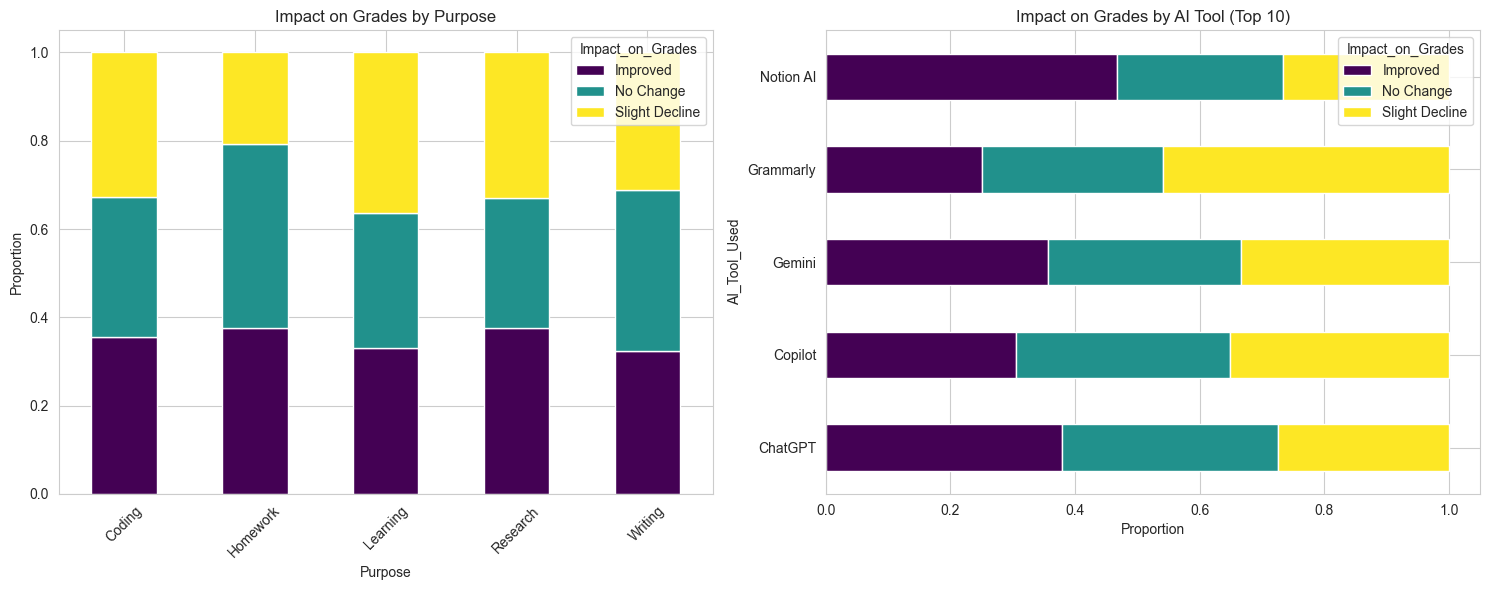

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))


purpose_impact = pd.crosstab(df['Purpose'], df['Impact_on_Grades'], normalize='index')
purpose_impact.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title('Impact on Grades by Purpose')
axes[0].set_xlabel('Purpose')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=45)


tool_impact = pd.crosstab(df['AI_Tool_Used'], df['Impact_on_Grades'], normalize='index')
tool_impact.head(10).plot(kind='barh', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Impact on Grades by AI Tool (Top 10)')
axes[1].set_xlabel('Proportion')

plt.tight_layout()
plt.show()

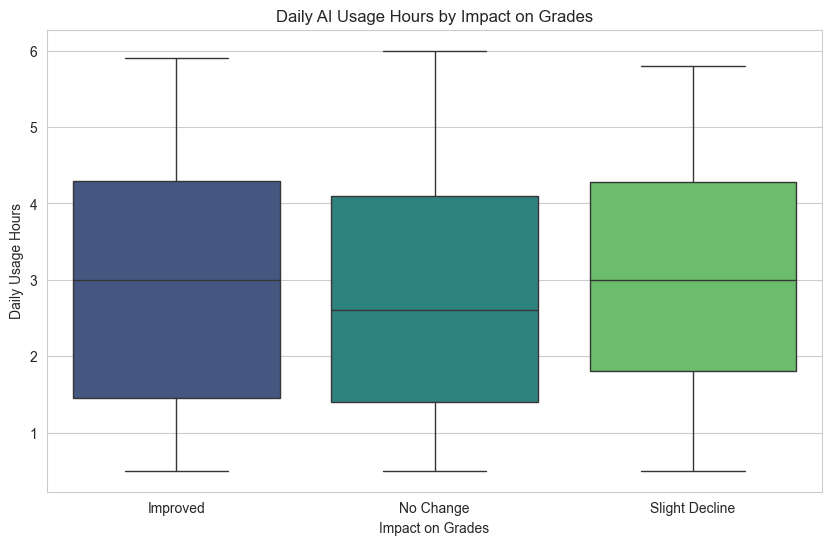

In [57]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Impact_on_Grades', y='Daily_Usage_Hours', data=df, palette='viridis', 
            order=['Improved', 'No Change', 'Slight Decline'])
plt.title('Daily AI Usage Hours by Impact on Grades')
plt.xlabel('Impact on Grades')
plt.ylabel('Daily Usage Hours')
plt.show()

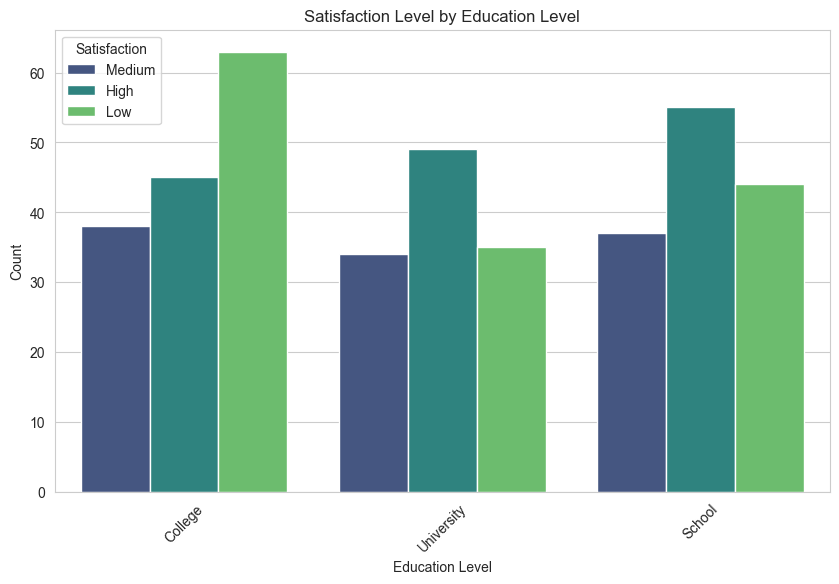

In [59]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Education_Level', hue='Satisfaction_Level', data=df, palette='viridis')
plt.title('Satisfaction Level by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Satisfaction')
plt.xticks(rotation=45)
plt.show()

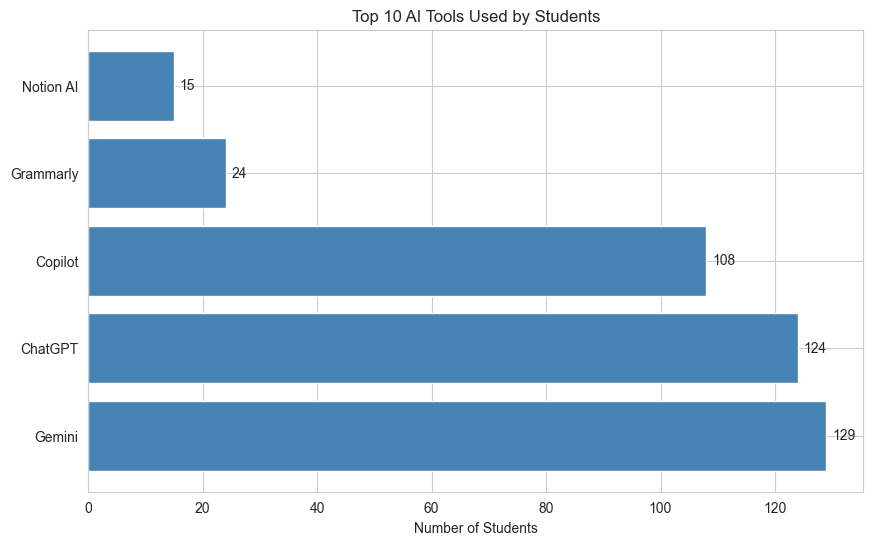

In [62]:
top_tools = df['AI_Tool_Used'].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_tools.index, top_tools.values, color='steelblue')
plt.xlabel('Number of Students')
plt.title('Top 10 AI Tools Used by Students')
for i, v in enumerate(top_tools.values):
    plt.text(v + 1, i, str(v), va='center')
plt.show()

## Проверка гипотез

### Гипотеза 1: Время использования ИИ влияет на успеваемость
* Нулевая гипотеза (H₀): Среднее время использования AI у студентов с улучшением оценок не отличается от времени у студентов со снижением оценок.
* Альтернативная гипотеза (H₁): Время использования AI различается между этими группами.

In [64]:
improved_usage = df[df['Impact_on_Grades'] == 'Improved']['Daily_Usage_Hours'].dropna()
declined_usage = df[df['Impact_on_Grades'] == 'Slight Decline']['Daily_Usage_Hours'].dropna()

if len(improved_usage) > 0 and len(declined_usage) > 0:
    mean_imp, mean_dec = improved_usage.mean(), declined_usage.mean()
    std_imp, std_dec = improved_usage.std(), declined_usage.std()
    n_imp, n_dec = len(improved_usage), len(declined_usage)
    
    std_error = np.sqrt((std_imp**2/n_imp) + (std_dec**2/n_dec))
    diff = abs(mean_imp - mean_dec)
    z_score = diff / std_error
    
    print(f"\nРезультаты:")
    print(f"  Improved: среднее = {mean_imp:.2f}ч, n = {n_imp}")
    print(f"  Declined: среднее = {mean_dec:.2f}ч, n = {n_dec}")
    print(f"  Разница = {diff:.2f}ч")
    print(f"  Z-оценка = {z_score:.2f}")


Результаты:
  Improved: среднее = 3.00ч, n = 139
  Declined: среднее = 3.02ч, n = 130
  Разница = 0.02ч
  Z-оценка = 0.11
